In [ ]:
# Clothing dataset for the workshop

!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 17.13 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (3783/3783), done.


In [ ]:
!ls -lh

total 8.0K
drwxr-xr-x 6 root root 4.0K Nov  3 19:49 clothing-dataset-small
drwxr-xr-x 1 root root 4.0K Oct 31 17:50 sample_data


The dataset contains:

* 10 clothing categories (dress, hat, longsleeve, outwear, pants, shirt, shoes, shorts, skirt, t-shirt)
* Training, validation, and test splits
* Pre-organized directory structure

## **1. Image Loading and Preprocessing**

Loading and Preprocessing Images

Images are represented as 3D arrays:

* Height × Width × Channels
* Channels: RGB (Red, Green, Blue)
* Each channel: 8 bits (0-255 values)

In [ ]:
import torch
from PIL import Image
import numpy as np

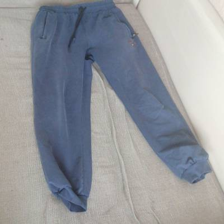

In [ ]:
# Load an image
img = Image.open('clothing-dataset-small/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')

# Resize to target size
img = img.resize((224, 224))
img

In [ ]:
# Convert image to numpy array
x = np.array(img)
print(x.shape)  # (224, 224, 3  <==> Height, width, Number of Channels (RGB))


(224, 224, 3)


array([[[179, 181, 176],
        [179, 181, 176],
        [179, 181, 176],
        ...,
        [237, 230, 222],
        [238, 231, 223],
        [236, 229, 221]],

       [[180, 181, 176],
        [177, 178, 173],
        [177, 178, 173],
        ...,
        [237, 230, 222],
        [237, 230, 222],
        [235, 228, 220]],

       [[178, 179, 174],
        [175, 176, 171],
        [175, 176, 171],
        ...,
        [237, 230, 222],
        [237, 230, 222],
        [234, 227, 219]],

       ...,

       [[155, 149, 137],
        [155, 149, 137],
        [158, 152, 140],
        ...,
        [157, 149, 138],
        [159, 151, 140],
        [156, 148, 137]],

       [[151, 145, 133],
        [152, 146, 134],
        [157, 151, 139],
        ...,
        [155, 147, 136],
        [157, 149, 138],
        [155, 147, 136]],

       [[150, 144, 132],
        [152, 146, 134],
        [157, 151, 139],
        ...,
        [154, 146, 135],
        [155, 147, 136],
        [153, 145, 134]]], dtype=uint8)
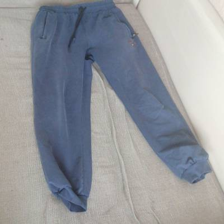

In [ ]:
x

## **2. Pre-trained Models (Using MobileNetV2)**

Instead of training from scratch, we'll use a model pre-trained on ImageNet (1.4M images, 1000 classes).

Note: https://docs.pytorch.org/vision/stable/models.html

In [ ]:
import torchvision.models as models
from torchvision import transforms

In [ ]:
# Load pre-trained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 157MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# Preprocessing for MobileNetV2
preprocess = transforms.Compose([
    transforms.Resize(256),                                     # resize
    transforms.CenterCrop(224),                                 # centre the image
    transforms.ToTensor(),                                      # convert image to Tensors for Pytorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),              # normalize to get smaller numbers for the Neural Network
])

In [ ]:
x = preprocess(img)
x

tensor([[[0.8276, 0.7933, 0.7762,  ..., 1.8379, 1.8208, 1.8037],
         [0.8447, 0.8104, 0.7933,  ..., 1.8379, 1.8037, 1.8037],
         [0.8618, 0.8276, 0.8104,  ..., 1.8550, 1.8037, 1.8037],
         ...,
         [0.7762, 0.7248, 0.7419,  ..., 0.8447, 0.8447, 0.7933],
         [0.7591, 0.7591, 0.7591,  ..., 0.8618, 0.8618, 0.8276],
         [0.7248, 0.6906, 0.6734,  ..., 0.8447, 0.8618, 0.8618]],

        [[0.9580, 0.9230, 0.9055,  ..., 1.9384, 1.9209, 1.9034],
         [0.9755, 0.9405, 0.9230,  ..., 1.9384, 1.9034, 1.9034],
         [0.9930, 0.9580, 0.9405,  ..., 1.9384, 1.8859, 1.9034],
         ...,
         [0.8004, 0.7479, 0.7654,  ..., 0.8704, 0.8704, 0.8179],
         [0.7829, 0.7829, 0.7829,  ..., 0.8529, 0.8704, 0.8354],
         [0.7479, 0.7129, 0.6954,  ..., 0.8354, 0.8529, 0.8529]],

        [[1.1062, 1.0714, 1.0539,  ..., 1.9951, 1.9777, 1.9603],
         [1.1237, 1.0888, 1.0714,  ..., 1.9951, 1.9603, 1.9603],
         [1.1411, 1.1062, 1.0888,  ..., 1.9951, 1.9428, 1.

In [ ]:
x.shape

torch.Size([3, 224, 224])

In [ ]:
# get batches of image as input into neural network (Batch_size = 1)
batch_t = torch.unsqueeze(x, 0)
batch_t.shape

torch.Size([1, 3, 224, 224])

* Now do the prediction:

In [ ]:
# Make prediction
with torch.no_grad():
    output = model(batch_t)
    print(output.shape)

torch.Size([1, 1000])


In [ ]:
# output for 1 image and 1000 predictions
output

tensor([[ 2.2427e+00, -2.0114e+00, -1.2542e-01, -6.6946e-01,  1.7635e+00,
         -1.3329e+00, -1.4026e+00, -1.3484e+00, -1.4840e+00, -4.0130e+00,
         -6.5940e+00, -5.4901e+00, -5.5818e+00, -3.5736e+00, -2.6900e+00,
         -5.0894e+00, -4.4860e+00, -4.8563e-01, -1.8529e+00, -3.4865e+00,
         -4.7337e+00, -1.4860e+00, -1.4399e+00, -7.9737e-01, -3.8429e+00,
         -2.3196e+00, -1.0433e+00, -1.8372e+00, -1.1772e+00, -9.1635e-01,
         -1.8537e+00, -1.5561e+00, -5.9366e-01,  8.1878e-01,  2.9164e+00,
         -1.7835e+00, -1.6100e+00, -2.0272e+00, -1.6498e+00, -1.4771e+00,
         -2.3772e+00, -3.0200e+00, -1.4916e+00, -9.4792e-01, -1.3502e+00,
         -1.4371e+00, -3.0592e+00, -1.8795e+00, -1.7403e+00, -2.2762e+00,
         -1.9235e+00,  4.0033e-02,  1.1635e+00, -1.9422e+00,  2.4749e-01,
         -3.4308e+00, -1.2632e+00, -1.6105e+00, -1.0462e+00, -7.5241e-01,
          5.5334e-01, -6.2871e-01, -1.7878e+00, -1.0621e+00, -1.6738e+00,
         -1.1067e+00,  2.0725e-02, -1.

In [ ]:
# Get top predictions from classes
_, indices = torch.sort(output, descending=True)
indices

tensor([[608, 834, 841, 474, 689, 824, 869, 906, 501, 885, 601, 457, 911, 735,
         655, 775, 697, 431, 610, 842, 568, 411, 617, 452, 678, 516, 797, 796,
         414, 578, 399, 434, 570, 630, 523, 591, 636, 793, 464, 435, 903, 658,
         840, 638, 515, 894, 588, 614, 691, 606, 502, 589, 465, 808, 672, 749,
         837, 780, 830, 529, 731, 728, 480, 643, 680, 419, 887, 514, 823, 790,
         876, 897, 459, 914, 451, 552, 785, 777, 473, 223, 389, 652, 772, 774,
         806, 490, 597, 233, 615, 512, 838, 836, 639, 667, 794, 702, 600, 715,
         153, 627, 258, 977, 520, 400,  34, 395, 499, 237, 177, 463, 861, 982,
         748, 585, 713, 559, 443, 487, 831, 999, 770, 676, 477, 257, 750, 882,
         183, 792, 169, 929, 151, 872, 602, 358, 587, 182, 584, 518, 195, 192,
         250, 391, 461, 265, 447, 170, 558, 259, 172, 811, 187, 224, 215, 700,
         801, 879,   0, 813, 851, 433, 204, 439, 534, 445, 683, 251, 256, 739,
         171, 416, 546, 173, 456, 222, 160, 741, 784

Let's see what's inside:

In [ ]:
# Get the ImageNET Classes of the trained neural network
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O imagenet_classes.txt

--2025-11-03 19:54:34--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2025-11-03 19:54:34 (62.7 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [ ]:
# Load ImageNet class names
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Get top 5 predictions
top5_indices = indices[0, :5].tolist()
top5_classes = [categories[i] for i in top5_indices]

print("Top 5 predictions:")
for i, class_name in enumerate(top5_classes):
    print(f"{i+1}: {class_name}")

Top 5 predictions:
1: jean
2: suit
3: sweatshirt
4: cardigan
5: overskirt


In [ ]:
#indices[0, :5].tolist()
#categories

## **3. Convolutional Neural Networks**
Convolutional Neural Networks (CNNs) are specialized neural networks for processing grid-like data such as images.

Key Components:

### Convolutional Layer: Extracts features using filters

  - Applies filters (e.g., 3×3, 5×5) to detect patterns
  - Creates feature maps (one per filter)
  - Detects edges, textures, shapes

### ReLU Activation: Introduces non-linearity

* f(x) = max(0, x)
* Sets negative values to 0
* Helps network learn complex patterns

### Pooling Layer: Down-samples feature maps

* Reduces spatial dimensions
* Max pooling: takes maximum value in a region
* Makes features more robust to small translations

### Fully Connected (Dense) Layer: Final classification

* Flattens 2D feature maps to 1D vector
* Connects to output classes

## CNN Workflow:

```Input Image → Conv + ReLU → Pooling → Conv + ReLU → Pooling → Flatten → Dense → Output```

## **4. Transfer Learning**

Transfer Learning reuses a model trained on one task (ImageNet) for a different task (clothing classification).

Approach:

1. Load pre-trained model (feature extractor)
2. Remove original classification head
3. Freeze convolutional layers
4. Add custom layers for our task
5. Train only the new layers

### Custom Dataset Class

* First, create a PyTorch Dataset to load images:

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image

class ClothingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

### Simple Preprocessing

In [ ]:
from torchvision import transforms

input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

### Create DataLoaders

In [ ]:
from torch.utils.data import DataLoader

train_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Build the Model

In [ ]:
import torch.nn as nn
import torchvision.models as models

class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        # Load pre-trained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Remove original classifier
        self.base_model.classifier = nn.Identity()

        # Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

### Train the Model

In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClothingClassifierMobileNet(num_classes=10)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)        # optimizer for the model
criterion = nn.CrossEntropyLoss()                          # entropy for multi-class classification

In [ ]:
# test the model with random image size

model.forward(torch.randn(1, 3, 224, 224).to(device))

tensor([[-0.1851,  0.2774,  0.1763, -0.4546, -0.3931, -0.1239,  0.0881,  0.5991,
          0.6697, -0.2318]], device='cuda:0', grad_fn=<AddmmBackward0>)

Now train it:

In [ ]:
%%time

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over the training data
    for inputs, labels in train_loader:
        # Move data to the specified device (GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()
        # Forward pass
        outputs = model(inputs)
        # Calculate the loss
        loss = criterion(outputs, labels)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate training loss
        running_loss += loss.item()
        # Get predictions
        _, predicted = torch.max(outputs.data, 1)
        # Update total and correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        # Iterate over the validation data
        for inputs, labels in val_loader:
            # Move data to the specified device (GPU or CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            # Forward pass
            outputs = model(inputs)
            # Calculate the loss
            loss = criterion(outputs, labels)

            # Accumulate validation loss
            val_loss += loss.item()
            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            # Update total and correct predictions
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate average validation loss and accuracy
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Print epoch results
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch 1/10
  Train Loss: 1.7191, Train Acc: 0.6265
  Val Loss: 0.7495, Val Acc: 0.7449
Epoch 2/10
  Train Loss: 0.7104, Train Acc: 0.7689
  Val Loss: 0.7958, Val Acc: 0.7155
Epoch 3/10
  Train Loss: 0.6941, Train Acc: 0.7911
  Val Loss: 0.7909, Val Acc: 0.7654
Epoch 4/10
  Train Loss: 0.5781, Train Acc: 0.8142
  Val Loss: 0.7817, Val Acc: 0.7742
Epoch 5/10
  Train Loss: 0.6412, Train Acc: 0.8214
  Val Loss: 0.8545, Val Acc: 0.7625
Epoch 6/10
  Train Loss: 0.5036, Train Acc: 0.8481
  Val Loss: 1.1244, Val Acc: 0.7537
Epoch 7/10
  Train Loss: 0.4952, Train Acc: 0.8475
  Val Loss: 1.0194, Val Acc: 0.7507
Epoch 8/10
  Train Loss: 0.5531, Train Acc: 0.8426
  Val Loss: 0.9884, Val Acc: 0.7771
Epoch 9/10
  Train Loss: 0.5017, Train Acc: 0.8589
  Val Loss: 1.2137, Val Acc: 0.7419
Epoch 10/10
  Train Loss: 0.3377, Train Acc: 0.8921
  Val Loss: 1.0408, Val Acc: 0.7771
CPU times: user 3min 5s, sys: 1.39 s, total: 3min 6s
Wall time: 3min 7s


It's a lower-level framework, that's why we need to implement some of these things like calculating accuracy on validation.

The line ```optimizer.zero_grad()``` is crucial in the training loop.

In PyTorch, gradients are accumulated by default. This means that if you don't zero the gradients before calculating the gradients for the current batch, the gradients from the previous batch will be added to the gradients of the current batch. This would lead to incorrect updates to your model's parameters.

By calling ```optimizer.zero_grad()```, you clear out the old gradients, ensuring that the gradients calculated during the ```loss.backward()``` call are only based on the current batch of data. This is essential for the optimizer to take the correct step during ```optimizer.step()```.

```model.train()``` and ```model.eval()``` are needed to manage the behavior of certain layers during training and evaluation.

```model.train()``` sets the model to training mode. In training mode, layers like Dropout and BatchNorm behave differently. Dropout layers are active (randomly dropping neurons), and BatchNorm layers update their running statistics (mean and variance) based on the current batch.

```model.eval()``` sets the model to evaluation mode. In evaluation mode, Dropout layers are inactive (they pass through all neurons), and BatchNorm layers use their accumulated running statistics instead of the current batch statistics. This ensures consistent behavior during inference and prevents randomness from affecting the evaluation results.

Let's put it inside a function so it's easier for us to call it:

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

## **5. Tuning the Learning Rate**

The learning rate controls how much to update model weights during training. It's one of the most important hyperparameters.

Analogy: Reading speed

* Too fast: Skip details, poor understanding (may not converge)
* Too slow: Never finish the book (training takes too long)
* Just right: Good comprehension and efficiency

Experimentation approach:

1. Try multiple values: [0.0001, 0.001, 0.01, 0.1]
2. Train for a few epochs each
3. Compare validation accuracy
4. Choose the rate with best performance and smallest train/val gap

* Function to train and optimize model

In [ ]:
def make_model(learning_rate=0.01):
    model = ClothingClassifierMobileNet(num_classes=10)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

Let's test different learning rates:

In [ ]:
%%time

learning_rates = [0.0001, 0.001, 0.01, 0.1]
num_epochs = 20

for lr in learning_rates:
    print(f'\n=== Learning Rate: {lr} ===')
    model, optimizer = make_model(learning_rate=lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Learning Rate: 0.0001 ===
Epoch 1/20
  Train Loss: 1.9983, Train Acc: 0.3008
  Val Loss: 1.7889, Val Acc: 0.4047
Epoch 2/20
  Train Loss: 1.6321, Train Acc: 0.4967
  Val Loss: 1.5070, Val Acc: 0.5249
Epoch 3/20
  Train Loss: 1.3960, Train Acc: 0.5815
  Val Loss: 1.3175, Val Acc: 0.5924
Epoch 4/20
  Train Loss: 1.2411, Train Acc: 0.6424
  Val Loss: 1.1800, Val Acc: 0.6364
Epoch 5/20
  Train Loss: 1.1298, Train Acc: 0.6780
  Val Loss: 1.0833, Val Acc: 0.6950
Epoch 6/20
  Train Loss: 1.0365, Train Acc: 0.7168
  Val Loss: 1.0134, Val Acc: 0.6950
Epoch 7/20
  Train Loss: 0.9623, Train Acc: 0.7386
  Val Loss: 0.9471, Val Acc: 0.7185
Epoch 8/20
  Train Loss: 0.9144, Train Acc: 0.7536
  Val Loss: 0.9049, Val Acc: 0.7361
Epoch 9/20
  Train Loss: 0.8590, Train Acc: 0.7647
  Val Loss: 0.8663, Val Acc: 0.7419
Epoch 10/20
  Train Loss: 0.8189, Train Acc: 0.7823
  Val Loss: 0.8299, Val Acc: 0.7537
Epoch 11/20
  Train Loss: 0.7847, Train Acc: 0.7872
  Val Loss: 0.8023, Val Acc: 0.7419
Epoch 12/2

The best learning rate is 0.001 (val_accuracy = 0.8152 (81.52%).

## **6. Adding Inner Layers**

We can add intermediate dense layers between feature extraction and output:

In [ ]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

Update make_model:

In [ ]:
def make_model(learning_rate=0.001, size_inner=100):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

Experiment with different sizes:

* Try: size_inner = [10, 100, 1000]
* Larger layers: more capacity, may overfit
* Smaller layers: faster, may underfit

Key points:

* Inner layer uses ReLU activation
* Output layer has no activation (logits)
* CrossEntropyLoss applies softmax internally

In [ ]:
%%time

# iterate through various size_inner with best learning rate from above
lr = 0.001
num_epochs = 20    # (number of epochs can be increased for more learning cycle)

for size_inner in [10, 100, 1000]:
    print("\n ==> size_inner =", size_inner)
    model, optimizer = make_model(learning_rate=lr, size_inner=size_inner)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


 ==> size_inner = 10
Epoch 1/20
  Train Loss: 1.8123, Train Acc: 0.4016
  Val Loss: 1.4639, Val Acc: 0.5161
Epoch 2/20
  Train Loss: 1.3394, Train Acc: 0.5293
  Val Loss: 1.1883, Val Acc: 0.5924
Epoch 3/20
  Train Loss: 1.1250, Train Acc: 0.6134
  Val Loss: 1.0518, Val Acc: 0.6452
Epoch 4/20
  Train Loss: 1.0117, Train Acc: 0.6613
  Val Loss: 0.9911, Val Acc: 0.6540
Epoch 5/20
  Train Loss: 0.9138, Train Acc: 0.6897
  Val Loss: 0.8928, Val Acc: 0.6862
Epoch 6/20
  Train Loss: 0.8547, Train Acc: 0.7115
  Val Loss: 0.8359, Val Acc: 0.7038
Epoch 7/20
  Train Loss: 0.8190, Train Acc: 0.7190
  Val Loss: 0.8254, Val Acc: 0.6950
Epoch 8/20
  Train Loss: 0.7679, Train Acc: 0.7383
  Val Loss: 0.7821, Val Acc: 0.7331
Epoch 9/20
  Train Loss: 0.7548, Train Acc: 0.7441
  Val Loss: 0.7821, Val Acc: 0.7302
Epoch 10/20
  Train Loss: 0.7097, Train Acc: 0.7598
  Val Loss: 0.7635, Val Acc: 0.7214
Epoch 11/20
  Train Loss: 0.7000, Train Acc: 0.7601
  Val Loss: 0.7519, Val Acc: 0.7361
Epoch 12/20
  Train

lr = 0.001, size_inner = 100, best_val_accuracy = 0.8240

## **7. Dropout Regularization**

Dropout randomly drops neurons during training to prevent overfitting.

How it works:

* Training: randomly set fraction of activations to 0
* Inference: use all neurons (dropout disabled automatically)
* Creates ensemble effect

Benefits:

* Prevents relying on specific features
* Forces learning robust patterns
* Reduces overfitting

In [ ]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

Update make_model function with droprate:

In [ ]:
def make_model(
        learning_rate=0.001,
        size_inner=100,
        droprate=0.2
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
%%time

# iterate through various droprate with best learning rate and size_inner from above. Also add more number of epochs
num_epochs = 20         #(epoch number can be increased to 30 or 50, so the model learns good while some parts of data is covered/dropped/patched )
lr = 0.001
size_inner = 100

for droprate in [0.1, 0.2, 0.3, 0.4]:
    print("\n ==> droprate =", droprate)
    model, optimizer = make_model(learning_rate=lr, size_inner=size_inner, droprate=droprate)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


 ==> droprate = 0.1
Epoch 1/20
  Train Loss: 1.3432, Train Acc: 0.5495
  Val Loss: 0.8512, Val Acc: 0.7390
Epoch 2/20
  Train Loss: 0.7886, Train Acc: 0.7503
  Val Loss: 0.6976, Val Acc: 0.7654
Epoch 3/20
  Train Loss: 0.6439, Train Acc: 0.7832
  Val Loss: 0.5754, Val Acc: 0.8006
Epoch 4/20
  Train Loss: 0.5623, Train Acc: 0.8184
  Val Loss: 0.5738, Val Acc: 0.7830
Epoch 5/20
  Train Loss: 0.4906, Train Acc: 0.8360
  Val Loss: 0.5348, Val Acc: 0.8152
Epoch 6/20
  Train Loss: 0.4472, Train Acc: 0.8553
  Val Loss: 0.5362, Val Acc: 0.8006
Epoch 7/20
  Train Loss: 0.4440, Train Acc: 0.8432
  Val Loss: 0.6013, Val Acc: 0.7977
Epoch 8/20
  Train Loss: 0.4062, Train Acc: 0.8576
  Val Loss: 0.5298, Val Acc: 0.8094
Epoch 9/20
  Train Loss: 0.4080, Train Acc: 0.8595
  Val Loss: 0.5830, Val Acc: 0.7889
Epoch 10/20
  Train Loss: 0.3631, Train Acc: 0.8761
  Val Loss: 0.5503, Val Acc: 0.8094
Epoch 11/20
  Train Loss: 0.3426, Train Acc: 0.8840
  Val Loss: 0.5845, Val Acc: 0.8035
Epoch 12/20
  Train 

Experimentation:

* Try: droprate = [0.0, 0.2, 0.5, 0.8]
* Typical values: 0.2 to 0.5
* Higher dropout may need more training epochs

(lr = 0.001, size_inner = 100, best_droprate = 0.3, best_val_accuracy = 0.8358)

## **8. Data Augmentation**

Data Augmentation artificially increases dataset size by applying random transformations to training images.

Common transformations:

* Rotation
* Horizontal/vertical flipping
* Zooming (random cropping)
* Shifting
* Shearing

Important rules:

* ✅ Apply ONLY to training data

* ❌ Never augment validation/test data

###Augmented Training Transforms

In [ ]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transforms WITH augmentation
train_transforms = transforms.Compose([
    transforms.RandomRotation(10),           # Rotate up to 10 degrees
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),  # Zoom
    transforms.RandomHorizontalFlip(),       # Horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation transforms - NO augmentation, same as before
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

* Apply Augmented transformation to the datasets below

In [ ]:
train_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [ ]:
def make_model(
        learning_rate=0.001,
        size_inner=100,
        droprate=0.2
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

When to use augmentation:

* Small datasets
* Risk of overfitting
* Images can appear in different orientations

Tips:

* Choose augmentations that make sense for your data
* Too much augmentation can hurt performance
* Usually requires longer training (more epochs)
* If no improvement after ~20 epochs, don't use it

## **9. Model Checkpointing**

Checkpointing saves the model during training to:

* Keep the best performing model
* Resume training if interrupted
* Avoid losing progress

###
TensorFlow/Keras equivalent:

* Keras: ModelCheckpoint callback
* PyTorch: Manual saving in training loop

Update the train and evaluation function. Save all models:

In [ ]:
def train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy = 0.0  # Initialize variable to track the best validation accuracy

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        # Checkpoint the model if validation accuracy improved
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            checkpoint_path = f'clothing_model_{epoch+1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

In [ ]:
%%time

# save model with added dropout rate
lr = 0.001
size_inner = 100
droprate = 0.3
num_epochs = 30       # you can use higher epochs here because of all model paramters

model, optimizer = make_model(learning_rate=lr, size_inner=size_inner, droprate=droprate)
train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1/30
  Train Loss: 1.5210, Train Acc: 0.4987
  Val Loss: 0.9815, Val Acc: 0.6833
Checkpoint saved: clothing_model_01_0.683.pth
Epoch 2/30
  Train Loss: 1.0183, Train Acc: 0.6679
  Val Loss: 0.7640, Val Acc: 0.7507
Checkpoint saved: clothing_model_02_0.751.pth
Epoch 3/30
  Train Loss: 0.8533, Train Acc: 0.7151
  Val Loss: 0.6689, Val Acc: 0.7683
Checkpoint saved: clothing_model_03_0.768.pth
Epoch 4/30
  Train Loss: 0.7743, Train Acc: 0.7432
  Val Loss: 0.6361, Val Acc: 0.7977
Checkpoint saved: clothing_model_04_0.798.pth
Epoch 5/30
  Train Loss: 0.6927, Train Acc: 0.7647
  Val Loss: 0.5939, Val Acc: 0.7859
Epoch 6/30
  Train Loss: 0.6870, Train Acc: 0.7559
  Val Loss: 0.6038, Val Acc: 0.7507
Epoch 7/30
  Train Loss: 0.6550, Train Acc: 0.7744
  Val Loss: 0.5758, Val Acc: 0.7947
Epoch 8/30
  Train Loss: 0.6247, Train Acc: 0.7865
  Val Loss: 0.5920, Val Acc: 0.7654
Epoch 9/30
  Train Loss: 0.6050, Train Acc: 0.7930
  Val Loss: 0.5708, Val Acc: 0.8065
Checkpoint saved: clothing_model_

### **10. Test the model with the best val accuracy and parameters on an image**

In [ ]:
path = '/content/clothing_model_30_0.842.pth'

In [ ]:
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.3, num_classes=10)
model.load_state_dict(torch.load(path))
model.to(device)
model.eval();

In [ ]:
# call the tensors of the preprocessed image
x

tensor([[[0.8276, 0.7933, 0.7762,  ..., 1.8379, 1.8208, 1.8037],
         [0.8447, 0.8104, 0.7933,  ..., 1.8379, 1.8037, 1.8037],
         [0.8618, 0.8276, 0.8104,  ..., 1.8550, 1.8037, 1.8037],
         ...,
         [0.7762, 0.7248, 0.7419,  ..., 0.8447, 0.8447, 0.7933],
         [0.7591, 0.7591, 0.7591,  ..., 0.8618, 0.8618, 0.8276],
         [0.7248, 0.6906, 0.6734,  ..., 0.8447, 0.8618, 0.8618]],

        [[0.9580, 0.9230, 0.9055,  ..., 1.9384, 1.9209, 1.9034],
         [0.9755, 0.9405, 0.9230,  ..., 1.9384, 1.9034, 1.9034],
         [0.9930, 0.9580, 0.9405,  ..., 1.9384, 1.8859, 1.9034],
         ...,
         [0.8004, 0.7479, 0.7654,  ..., 0.8704, 0.8704, 0.8179],
         [0.7829, 0.7829, 0.7829,  ..., 0.8529, 0.8704, 0.8354],
         [0.7479, 0.7129, 0.6954,  ..., 0.8354, 0.8529, 0.8529]],

        [[1.1062, 1.0714, 1.0539,  ..., 1.9951, 1.9777, 1.9603],
         [1.1237, 1.0888, 1.0714,  ..., 1.9951, 1.9603, 1.9603],
         [1.1411, 1.1062, 1.0888,  ..., 1.9951, 1.9428, 1.

In [ ]:
# transform image
x = val_transforms(img)
batch_t = torch.unsqueeze(x, 0).to(device)

# Make prediction
with torch.no_grad():
    output = model(batch_t)

# Get top predictions from classes
_, indices = torch.sort(output, descending=True)

In [ ]:
output         # class 4 is the highest probabiltity outcome

tensor([[-0.4054, -6.5197, -2.0090, -3.3830,  7.6997, -1.3894, -4.8367, -0.9261,
         -2.5470, -6.8548]], device='cuda:0')

In [ ]:
indices       # class 4 is the outcome after sorting

tensor([[4, 0, 7, 5, 2, 8, 3, 6, 1, 9]], device='cuda:0')

In [ ]:
# Get the actual image class of the outcome

train_dataset.class_to_idx

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

## **11. Using the Trained Model in another way**


### Loading a Saved Model

In [ ]:
import glob

# Find best checkpoint
list_of_files = glob.glob('clothing_model_*.pth')
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Loading model from: {latest_file}")

# Load model
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.3, num_classes=10)
model.load_state_dict(torch.load(latest_file))
model.to(device)
model.eval()

Loading model from: clothing_model_30_0.842.pth


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [ ]:
# transform image
x = val_transforms(img)
batch_t = torch.unsqueeze(x, 0).to(device)

# Make prediction
with torch.no_grad():
    output = model(batch_t)

# Get top predictions from classes
_, indices = torch.sort(output, descending=True)

In [ ]:
pred_proba = output[0].tolist()
pred_proba

[-0.4054122269153595,
 -6.519736289978027,
 -2.008991241455078,
 -3.383040189743042,
 7.699722766876221,
 -1.389441728591919,
 -4.836723327636719,
 -0.9261423349380493,
 -2.547004222869873,
 -6.854765892028809]

In [ ]:
classes = list(train_dataset.class_to_idx)
classes

['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']

In [ ]:
list(zip(pred_proba, classes))

[(-0.4054122269153595, 'dress'),
 (-6.519736289978027, 'hat'),
 (-2.008991241455078, 'longsleeve'),
 (-3.383040189743042, 'outwear'),
 (7.699722766876221, 'pants'),
 (-1.389441728591919, 'shirt'),
 (-4.836723327636719, 'shoes'),
 (-0.9261423349380493, 'shorts'),
 (-2.547004222869873, 'skirt'),
 (-6.854765892028809, 't-shirt')]

### Making Predictions using Keras and an image URL

In [ ]:
!pip install keras_image_helper

In [ ]:
from keras_image_helper import create_preprocessor
import numpy as np

def preprocess_pytorch_style(X):
    # X: shape (1, 224, 224, 3), dtype=float32, values in [0, 255]
    X = X / 255.0

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)

    # Convert NHWC → NCHW (batch, height, width, channels → batch, channels, height, width)
    X = X.transpose(0, 3, 1, 2)

    # Normalize
    X = (X - mean) / std

    return X.astype(np.float32)

preprocessor = create_preprocessor(preprocess_pytorch_style, target_size=(224, 224))

# Predict from URL
url = 'http://bit.ly/mlbookcamp-pants'
X = preprocessor.from_url(url)
X = torch.Tensor(X).to(device)

with torch.no_grad():
    pred = model(X).cpu().numpy()[0]

classes = [
    "dress", "hat", "longsleeve", "outwear", "pants",
    "shirt", "shoes", "shorts", "skirt", "t-shirt"
]

result = dict(zip(classes, pred.tolist()))
print(result)

{'dress': -0.6159797310829163, 'hat': -9.704877853393555, 'longsleeve': -1.7349028587341309, 'outwear': 0.3046879172325134, 'pants': 6.443881034851074, 'shirt': -1.168724775314331, 'shoes': -8.07792854309082, 'shorts': 1.0771825313568115, 'skirt': -5.453442573547363, 't-shirt': -4.495481491088867}


## **11. Exporting to ONNX**

ONNX (Open Neural Network Exchange) is a format for model interoperability.

Benefits:

* Deploy on different platforms
* Use optimized runtimes (ONNX Runtime)
* Better inference performance
* Language-agnostic deployment

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 131.3 MB/s eta 0:00:00


In [ ]:
# model

In [ ]:
# Create dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
onnx_path = "clothing_classifier.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Model exported to {onnx_path}")

/tmp/ipython-input-4289306761.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Model exported to clothing_classifier.onnx


## **Key Concepts Learned**

1. Transfer Learning: Reuse pre-trained models for new tasks
2. CNN Architecture: Conv layers → Pooling → Dense layers
3. Hyperparameter Tuning: Learning rate is critical
4. Regularization: Dropout prevents overfitting
5. Data Augmentation: Increases effective dataset size
6. Model Checkpointing: Save best models during training
7. PyTorch Workflow: Dataset → DataLoader → Model → Training Loop

## **Best Practices**

1. Start with pre-trained models (transfer learning)
2. Freeze convolutional layers initially
3. Use appropriate normalization (match pre-training)
4. Experiment with one hyperparameter at a time
5. Monitor train/val gap for overfitting
6. Use checkpointing to save best models
7. Augment training data only, not validation
8. Train longer with dropout and augmentation
9. Use GPU when available: torch.cuda.is_available()

## **Next Steps**

* Try different pre-trained models (ResNet, EfficientNet)
* Experiment with learning rate schedulers
* Fine-tune the entire model (unfreeze convolutional layers)
* Try different optimizers (SGD with momentum, AdamW)
* Deploy the ONNX model

## Note: The ONNX model can now be served with AWS lambda_function (serverless). Watch this video (https://www.youtube.com/watch?v=sHQaeVm5hT8) for lecture.